In [1]:
import pandas as pd
data=pd.read_csv('/Users/medhanshpindi/Desktop/IntelliUnderwrite/IntelliUnderwrite/ML/Dataset/credit_train.csv')
df=pd.DataFrame(data)
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [2]:
df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='str')

In [3]:
cols=['Loan Status','Current Loan Amount','Credit Score','Annual Income','Monthly Debt']
df1=df[cols]
df1.head(5)

,Loan Status,Current Loan Amount,Credit Score,Annual Income,Monthly Debt
0,Fully Paid,445412.0,709.0,1167493.0,5214.74
1,Fully Paid,262328.0,NaN,NaN,33295.98
2,Fully Paid,99999999.0,741.0,2231892.0,29200.53
3,Fully Paid,347666.0,721.0,806949.0,8741.90
4,Fully Paid,176220.0,NaN,NaN,20639.70


In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Loan Status          100000 non-null  str    
 1   Current Loan Amount  100000 non-null  float64
 2   Credit Score         80846 non-null   float64
 3   Annual Income        80846 non-null   float64
 4   Monthly Debt         100000 non-null  float64
dtypes: float64(4), str(1)
memory usage: 3.8 MB


In [5]:
df1.isna().sum()

Loan Status              514
Current Loan Amount      514
Credit Score           19668
Annual Income          19668
Monthly Debt             514
dtype: int64

In [6]:
df1.dropna(inplace=True)

In [7]:
df1.isna().sum()

Loan Status            0
Current Loan Amount    0
Credit Score           0
Annual Income          0
Monthly Debt           0
dtype: int64

In [8]:
df1.duplicated().sum()

np.int64(10215)

In [9]:
df1.drop_duplicates(inplace=True)

In [10]:
df1.columns

Index(['Loan Status', 'Current Loan Amount', 'Credit Score', 'Annual Income',
       'Monthly Debt'],
      dtype='str')

In [11]:
df1['Loan Status'].value_counts()

Loan Status
Fully Paid     53421
Charged Off    17210
Name: count, dtype: int64

In [12]:
df1.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt
count,7.063100e+04,70631.000000,7.063100e+04,70631.000000
mean,1.652005e+07,1130.830598,1.375894e+06,18420.116941
std,3.678494e+07,1571.037395,1.104852e+06,12205.089401
min,1.124200e+04,585.000000,7.662700e+04,0.000000
25%,1.904210e+05,708.000000,8.479320e+05,10180.960000
50%,3.268980e+05,729.000000,1.168975e+06,16152.470000
75%,5.678310e+05,742.000000,1.648915e+06,23932.875000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000


count       70631.000000
mean     16520050.481233
std      36784942.986809
min         11242.000000
25%        190421.000000
50%        326898.000000
75%        567831.000000
max      99999999.000000
Name: Current Loan Amount, dtype: str


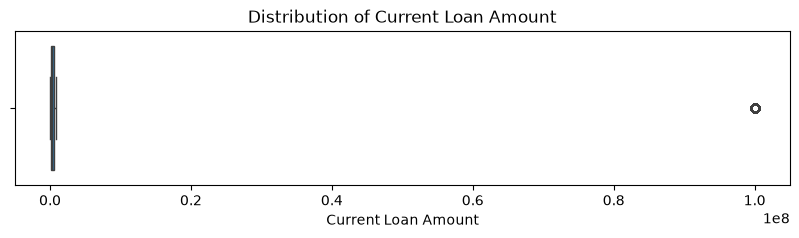

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check the mathematical distribution and maximums
print(df1['Current Loan Amount'].describe().apply(lambda x: format(x, 'f')))

# 2. Visualize the spread to identify artificial data caps
plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['Current Loan Amount'])
plt.title('Distribution of Current Loan Amount')
plt.show()

In [14]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df1['Current Loan Amount'].quantile(0.25)
Q3 = df1['Current Loan Amount'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the upper bound (1.5x IQR is the statistical standard)
upper_bound = Q3 + 1.5 * IQR

# 3. Filter df1 to keep only statistically valid loans and enforce a logical minimum of 500
df1 = df1[(df1['Current Loan Amount'] >= 500) & (df1['Current Loan Amount'] <= upper_bound)].copy()

# 4. Verify the trim
print(f"Maximum valid loan amount retained: {upper_bound:.2f}")
print(f"Clean rows remaining: {len(df1)}")

Maximum valid loan amount retained: 1133946.00
Clean rows remaining: 59147


count    59147.000000
mean      1209.480971
std       1705.643486
min        585.000000
25%        707.000000
50%        727.000000
75%        742.000000
max       7510.000000
Name: Credit Score, dtype: float64


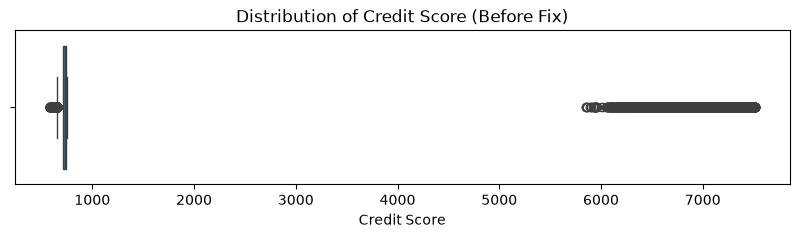

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check the raw distribution (you will likely see a max value > 7000)
print(df1['Credit Score'].describe())

# 2. Visualize the extreme gap caused by the data entry error
plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['Credit Score'])
plt.title('Distribution of Credit Score (Before Fix)')
plt.show()

Clean rows remaining: 59147
count    59147.000000
mean       717.187042
std         28.524811
min        585.000000
25%        704.000000
50%        724.000000
75%        739.000000
max        751.000000
Name: Credit Score, dtype: float64


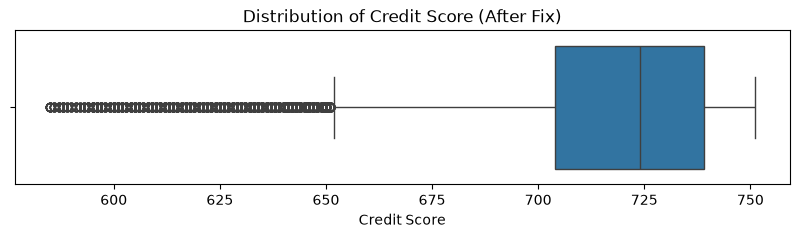

In [16]:
# 1. Fix the typo: If a score is above 850, divide it by 10 to normalize it
df1['Credit Score'] = df1['Credit Score'].apply(lambda x: x / 10 if x > 850 else x)

# 2. Enforce hard FICO boundaries (300 minimum, 850 maximum)
df1 = df1[(df1['Credit Score'] >= 300) & (df1['Credit Score'] <= 850)].copy()

# 3. Verify the clean distribution
print(f"Clean rows remaining: {len(df1)}")
print(df1['Credit Score'].describe())

# 4. Plot the corrected data
plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['Credit Score'])
plt.title('Distribution of Credit Score (After Fix)')
plt.show()

--- Before Trim ---
count        59147.000000
mean       1369532.472213
std        1135080.425361
min          76627.000000
25%         844464.500000
50%        1165536.000000
75%        1640279.500000
max      165557393.000000
Name: Annual Income, dtype: str

--- After Trim ---
Maximum valid income retained: 2834002.00
Clean rows remaining: 56341


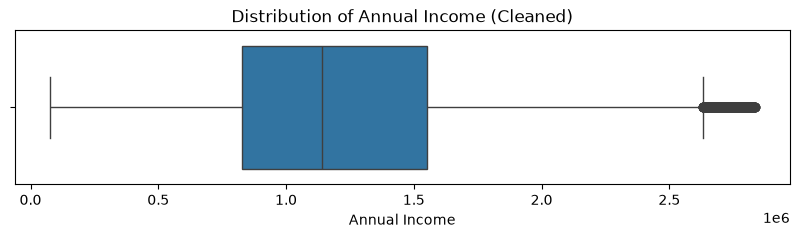

In [17]:
# 1. Diagnose Annual Income
print("--- Before Trim ---")
print(df1['Annual Income'].describe().apply(lambda x: format(x, 'f')))

# 2. Calculate IQR for Annual Income
Q1_inc = df1['Annual Income'].quantile(0.25)
Q3_inc = df1['Annual Income'].quantile(0.75)
IQR_inc = Q3_inc - Q1_inc

# 3. Define the upper bound (1.5x IQR)
upper_bound_inc = Q3_inc + 1.5 * IQR_inc

# 4. Filter the DataFrame (ensuring income is > 0 and removing extreme upper tails)
df1 = df1[(df1['Annual Income'] > 0) & (df1['Annual Income'] <= upper_bound_inc)].copy()

# 5. Verify the trim
print("\n--- After Trim ---")
print(f"Maximum valid income retained: {upper_bound_inc:.2f}")
print(f"Clean rows remaining: {len(df1)}")

plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['Annual Income'])
plt.title('Distribution of Annual Income (Cleaned)')
plt.show()

--- Before Trim ---
count    56341.000000
mean     17460.844438
std      10369.173323
min          0.000000
25%       9993.430000
50%      15754.040000
75%      23078.160000
max      79808.170000
Name: Monthly Debt, dtype: str


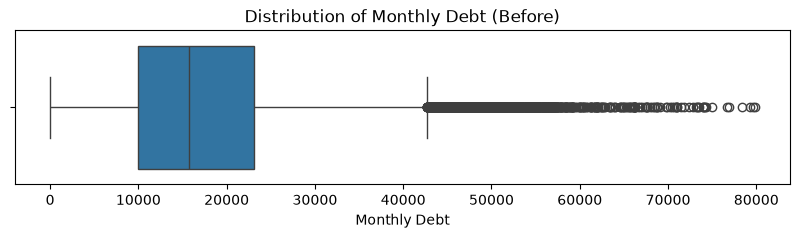


--- After Trim ---
Maximum valid monthly debt retained: 42705.26
Clean rows remaining: 54995


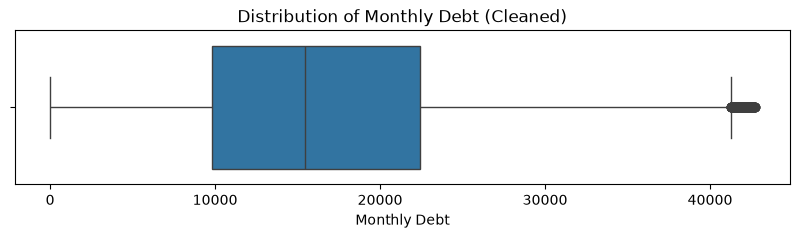

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Diagnose Monthly Debt Before Trim
print("--- Before Trim ---")
print(df1['Monthly Debt'].describe().apply(lambda x: format(x, 'f')))

plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['Monthly Debt'])
plt.title('Distribution of Monthly Debt (Before)')
plt.show()

# 2. Calculate IQR for Monthly Debt
Q1_debt = df1['Monthly Debt'].quantile(0.25)
Q3_debt = df1['Monthly Debt'].quantile(0.75)
IQR_debt = Q3_debt - Q1_debt

# 3. Define the upper bound (1.5x IQR)
# We set a hard lower bound of 0 because negative debt doesn't exist
upper_bound_debt = Q3_debt + 1.5 * IQR_debt

# 4. Filter df1 to remove extreme debt profiles
df1 = df1[(df1['Monthly Debt'] >= 0) & (df1['Monthly Debt'] <= upper_bound_debt)].copy()

# 5. Verify the clean data
print("\n--- After Trim ---")
print(f"Maximum valid monthly debt retained: {upper_bound_debt:.2f}")
print(f"Clean rows remaining: {len(df1)}")

plt.figure(figsize=(10, 2))
sns.boxplot(x=df1['Monthly Debt'])
plt.title('Distribution of Monthly Debt (Cleaned)')
plt.show()

In [19]:
# 1. Engineer the DTI column (Monthly Debt divided by Monthly Income)
# Adding a tiny epsilon (0.01) to the denominator prevents DivisionByZero errors just in case
df1['dti'] = df1['Monthly Debt'] / ((df1['Annual Income'] / 12) + 0.01)

# 2. Round the result for clean data handling
df1['dti'] = df1['dti'].round(4)

# 3. Preview the first 5 rows to verify the calculation worked
print(df1[['Annual Income', 'Monthly Debt', 'dti']].head())

   Annual Income  Monthly Debt     dti
0      1167493.0       5214.74  0.0536
3       806949.0       8741.90  0.1300
5       896857.0      16367.74  0.2190
6      1184194.0      10855.08  0.1100
8      2559110.0      18660.28  0.0875


In [20]:
df1.head()

,Loan Status,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,dti
0,Fully Paid,445412.0,709.0,1167493.0,5214.74,0.0536
3,Fully Paid,347666.0,721.0,806949.0,8741.90,0.1300
5,Charged Off,206602.0,729.0,896857.0,16367.74,0.2190
6,Fully Paid,217646.0,730.0,1184194.0,10855.08,0.1100
8,Fully Paid,548746.0,678.0,2559110.0,18660.28,0.0875


In [21]:
df1.drop('Monthly Debt', axis=1, inplace=True)   

In [22]:
df1.head()

,Loan Status,Current Loan Amount,Credit Score,Annual Income,dti
0,Fully Paid,445412.0,709.0,1167493.0,0.0536
3,Fully Paid,347666.0,721.0,806949.0,0.1300
5,Charged Off,206602.0,729.0,896857.0,0.2190
6,Fully Paid,217646.0,730.0,1184194.0,0.1100
8,Fully Paid,548746.0,678.0,2559110.0,0.0875


In [23]:
df1.describe()

,Current Loan Amount,Credit Score,Annual Income,dti
count,54995.000000,54995.000000,5.499500e+04,54995.000000
mean,297386.417929,717.357760,1.209424e+06,0.173092
std,174676.725568,28.225173,5.195862e+05,0.078755
min,11242.000000,585.000000,7.662700e+04,0.000000
25%,165154.000000,704.000000,8.175890e+05,0.115000
50%,262152.000000,724.000000,1.129284e+06,0.170000
75%,403172.000000,739.000000,1.517568e+06,0.228000
max,789250.000000,751.000000,2.833755e+06,0.400000


In [24]:
# 1. Convert 'Loan Status' to integers (1 = Charged Off / Default, 0 = Fully Paid)
df1['Loan Status'] = df1['Loan Status'].apply(lambda x: 1 if str(x).strip() == 'Charged Off' else 0)

# 2. Reset the index permanently, dropping the old scattered index
df1 = df1.reset_index(drop=True)

# 3. Verify the binary conversion and the clean index
print("--- Class Distribution ---")
print(df1['Loan Status'].value_counts())

print("\n--- Cleaned DataFrame Preview ---")
print(df1.head())

--- Class Distribution ---
Loan Status
0    38811
1    16184
Name: count, dtype: int64

--- Cleaned DataFrame Preview ---
   Loan Status  Current Loan Amount  Credit Score  Annual Income     dti
0            0             445412.0         709.0      1167493.0  0.0536
1            0             347666.0         721.0       806949.0  0.1300
2            1             206602.0         729.0       896857.0  0.2190
3            0             217646.0         730.0      1184194.0  0.1100
4            0             548746.0         678.0      2559110.0  0.0875


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

# 1. Define your 4 core features and target
X = df1[['Current Loan Amount', 'Credit Score', 'Annual Income', 'dti']]
y = df1['Loan Status']

# 2. Perform the 80/20 split on your 54,995 clean rows
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale the financial numbers so XGBoost treats them equally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Calculate exact imbalance to make the model respect 'Charged Off' applicants
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 5. Initialize and train the IntelliUnderwrite Traditional Baseline
print("Training traditional baseline model...")
baseline_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=imbalance_ratio,
    eval_metric='logloss',
    random_state=42
)
baseline_model.fit(X_train_scaled, y_train)

# 6. Evaluate the model on the hidden 20%
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]
y_pred = baseline_model.predict(X_test_scaled)

print("\n🚀 --- OFFICIAL BASELINE RESULTS ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training traditional baseline model...

🚀 --- OFFICIAL BASELINE RESULTS ---
ROC-AUC Score: 0.6358

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.59      0.67      7762
           1       0.38      0.60      0.47      3237

    accuracy                           0.59     10999
   macro avg       0.58      0.60      0.57     10999
weighted avg       0.66      0.59      0.61     10999



In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import time

# 1. Initialize models with strict class weighting to handle the 3:1 imbalance
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='logloss', random_state=42)
}

# 2. Define the Hyperparameter Grids
param_grids = {
    "Logistic Regression": {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    },
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 7, 10],            # Kept shallow to prevent overfitting
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],            # Prevents memorization of the data
        'colsample_bytree': [0.8, 1.0]      # Randomly drops columns per tree
    }
}

# 3. Execute the Tuning Arena
best_models = {}

for name in models.keys():
    print(f"Tuning {name}...")
    start_time = time.time()
    
    search = RandomizedSearchCV(
        estimator=models[name],
        param_distributions=param_grids[name],
        n_iter=10,         # Tests 10 random combinations per model
        scoring='roc_auc', # Optimizes strictly for ROC-AUC
        cv=3,              # 3-fold cross validation
        verbose=0,
        random_state=42,
        n_jobs=-1          # Utilizes all available CPU cores
    )
    
    search.fit(X_train_scaled, y_train)
    best_models[name] = search.best_estimator_
    
    elapsed_time = time.time() - start_time
    print(f"✅ {name} Cross-Val AUC: {search.best_score_:.4f} (Took {elapsed_time:.1f} sec)")
    print(f"   Best Params: {search.best_params_}\n")

# 4. Final Evaluation of the Winner on the hidden Test Set
best_xgb = best_models['XGBoost']
y_pred_proba_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]
print(f"🏆 Tuned XGBoost Final Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Tuning Logistic Regression...
✅ Logistic Regression Cross-Val AUC: 0.6295 (Took 2.5 sec)
   Best Params: {'solver': 'liblinear', 'C': 10}

Tuning Random Forest...
✅ Random Forest Cross-Val AUC: 0.6373 (Took 22.8 sec)
   Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 7}

Tuning XGBoost...
✅ XGBoost Cross-Val AUC: 0.6411 (Took 1.5 sec)
   Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

🏆 Tuned XGBoost Final Test ROC-AUC: 0.6432


In [29]:
import joblib

# 1. Export the Tuned XGBoost Model
joblib.dump(best_xgb, 'baseline_xgboost_model.pkl')

# 2. Export the StandardScaler (Critical for future predictions)
joblib.dump(scaler, 'baseline_scaler.pkl')

# 3. Export the clean dataset just in case we need it for the next phase
df1.to_csv('cleaned_baseline_data.csv', index=False)

print("✅ Model, Scaler, and Clean Data successfully exported!")

✅ Model, Scaler, and Clean Data successfully exported!
